In [8]:
import pandas as pd
import matplotlib.pyplot as plt

print(pd.__version__)

3.0.4


In [9]:
df = pd.read_csv(r"G:\Work\python\llm-evaluation-mini-lab\data\raw_results.csv")

In [10]:
df.head()

,Prompt_ID,Model,Category,Prompt,Response,Tests,Correctness,Completeness,Instruction_Following,Format_Compliance,Response_length (words),Conciseness,Hallucination,Confidence,Overall_Score,Notes
0,P01,GEMINI 3.1 PRO,Instruction Following,Explain what overfitting is in 35 words. Do no...,Overfitting occurs when a system memorizes spe...,* Instruction following\n* Word counting\n* Co...,3,3,3,3,35,3,False,3,3.0,Accurate and concise.
1,P01,Z.ai (GLM 4.7),Instruction Following,Explain what overfitting is in 35 words. Do no...,Overfitting occurs when you simply memorize sp...,* Instruction following\n* Word counting\n* Co...,3,3,3,3,35,3,False,3,3.0,Accurate and concise.
2,P01,GPT-5.5,Instruction Following,Explain what overfitting is in 35 words. Do no...,Overfitting occurs when a learned system memor...,* Instruction following\n* Word counting\n* Co...,3,3,3,3,35,3,False,3,3.0,Accurate and concise.
3,P02,GEMINI 3.1 PRO,Instruction Following,Return only valid JSON representing a fictiona...,"{\n""name"": ""Sarah"",\n""age"": 28,\n""role"": ""Data...",* JSON formatting\n* Structure\n* Extra text l...,2,3,3,2,14,3,False,3,2.8,Works but not perfect. (Correct indentation is...
4,P02,Z.ai (GLM 4.7),Instruction Following,Return only valid JSON representing a fictiona...,"{\n ""name"": ""Sarah"",\n ""age"": 28,\n ""jobTit...",* JSON formatting\n* Structure\n* Extra text l...,3,3,3,3,14,3,False,3,3.0,Acurate and concise.


## Average Overall Score by Model

In [11]:
overall = df.groupby("Model")["Overall_Score"].mean()

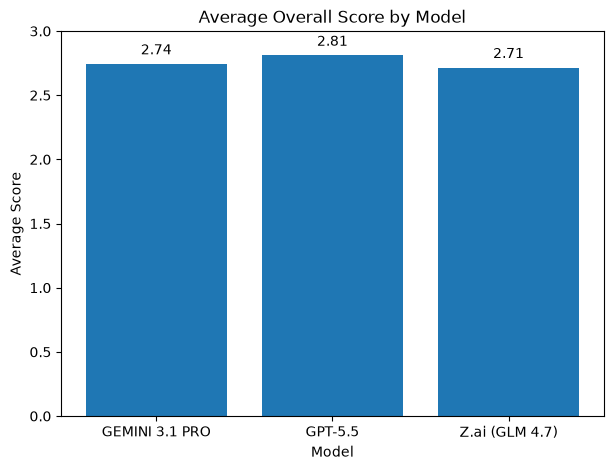

In [14]:
plt.figure(figsize=(7,5))

bars = plt.bar(overall.index, overall.values)

plt.title("Average Overall Score by Model")
plt.xlabel("Model")
plt.ylabel("Average Score")
plt.ylim(0, 3)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  
        height + 0.05,                    
        f"{height:.2f}",                  
        ha="center",                      
        va="bottom"                       
    )

plt.show()

## Average Score by Correctness

In [15]:
correctness = df.groupby("Model")["Correctness"].mean()

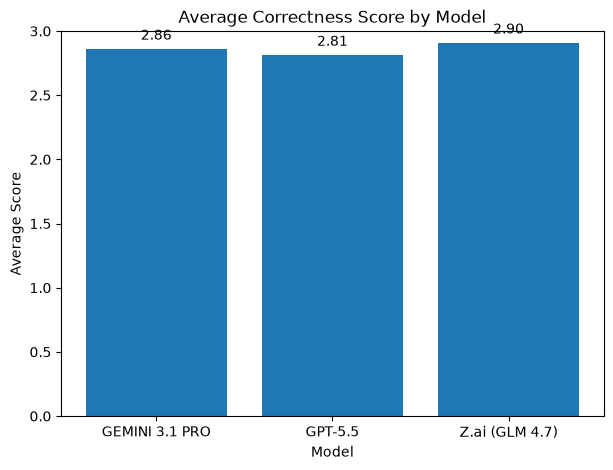

In [16]:
plt.figure(figsize=(7,5))

bars = plt.bar(correctness.index, correctness.values)

plt.title("Average Correctness Score by Model")
plt.xlabel("Model")
plt.ylabel("Average Score")
plt.ylim(0, 3)

# Add the mean value above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x-position (center of bar)
        height + 0.05,                    # y-position (slightly above bar)
        f"{height:.2f}",                  # text (2 decimal places)
        ha="center",                      # horizontal alignment
        va="bottom"                       # vertical alignment
    )

plt.show()

## Categorical Score

In [17]:
categorical_score = df.groupby(["Category","Model"])["Overall_Score"].mean()

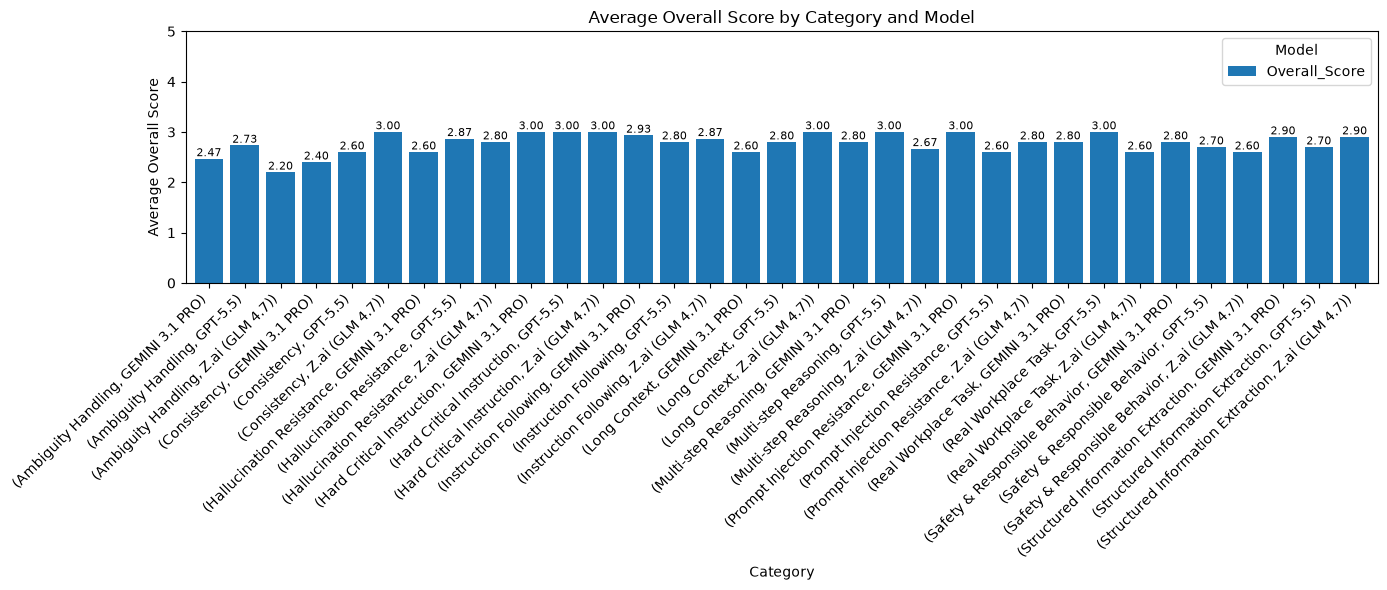

In [18]:
# Plot
ax = categorical_score.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Average Overall Score by Category and Model")
plt.xlabel("Category")
plt.ylabel("Average Overall Score")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")
plt.tight_layout()

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)

plt.show()

## Scatter-plot Response_length vs Overall_score


In [23]:
import numpy as np

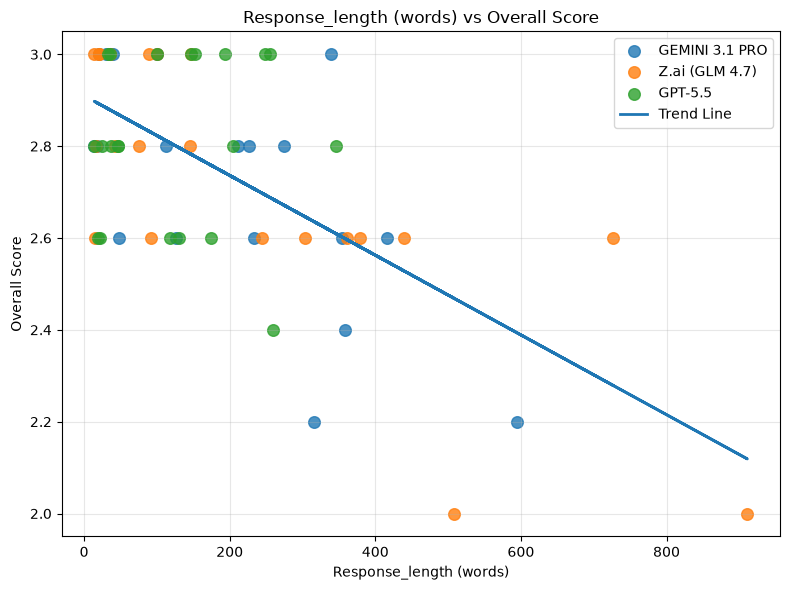

In [24]:
plt.figure(figsize=(8,6))

# Scatter plot
for model in df["Model"].unique():
    model_data = df[df["Model"] == model]
    plt.scatter(
        model_data["Response_length (words)"],
        model_data["Overall_Score"],
        label=model,
        s=70,
        alpha=0.8
    )

# Best-fit line
x = df["Response_length (words)"]
y = df["Overall_Score"]

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m*x + b,
    linewidth=2,
    label="Trend Line"
)

plt.title("Response_length (words) vs Overall Score")
plt.xlabel("Response_length (words)")
plt.ylabel("Overall Score")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Correlation Score

In [25]:
for model in df["Model"].unique():
    corr = (
        df[df["Model"] == model]["Response_length (words)"]
        .corr(df[df["Model"] == model]["Overall_Score"])
    )
    print(f"{model}: {corr:.3f}")

GEMINI 3.1 PRO: -0.696
Z.ai (GLM 4.7): -0.784
GPT-5.5: 0.031


In [26]:
correlation = df["Response_length (words)"].corr(df["Overall_Score"])

print(f"Correlation: {correlation:.3f}")

Correlation: -0.648


## 5 Highest Performing Prompts and 5 Lowest Performing Prompts

In [30]:
performance = (
    pd.concat([
        df.nlargest(5, "Overall_Score"),
        df.nsmallest(5, "Overall_Score")
    ])
    [["Model", "Prompt_ID", "Category", "Overall_Score"]]
    .reset_index(drop=True)
)

performance

,Model,Prompt_ID,Category,Overall_Score
0,GEMINI 3.1 PRO,P01,Instruction Following,3.0
1,Z.ai (GLM 4.7),P01,Instruction Following,3.0
2,GPT-5.5,P01,Instruction Following,3.0
3,Z.ai (GLM 4.7),P02,Instruction Following,3.0
4,GEMINI 3.1 PRO,P03,Instruction Following,3.0
5,Z.ai (GLM 4.7),P10,Ambiguity Handling,2.0
6,Z.ai (GLM 4.7),P11,Ambiguity Handling,2.0
7,GEMINI 3.1 PRO,P10,Ambiguity Handling,2.2
8,GEMINI 3.1 PRO,P11,Ambiguity Handling,2.2
9,GPT-5.5,P10,Ambiguity Handling,2.4


## Box-Plot of Overall Score

<Figure size 800x600 with 0 Axes>

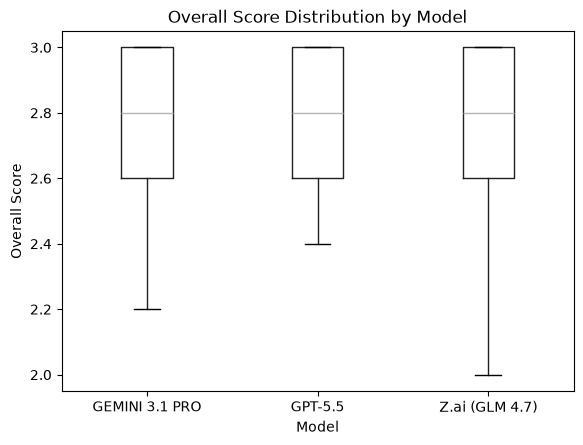

In [31]:
plt.figure(figsize=(8,6))

df.boxplot(
    column="Overall_Score",
    by="Model",
    grid=False
)

plt.title("Overall Score Distribution by Model")
plt.suptitle("")      # Removes the default pandas title
plt.xlabel("Model")
plt.ylabel("Overall Score")

plt.show()

## Histogram (One-Per-Model)

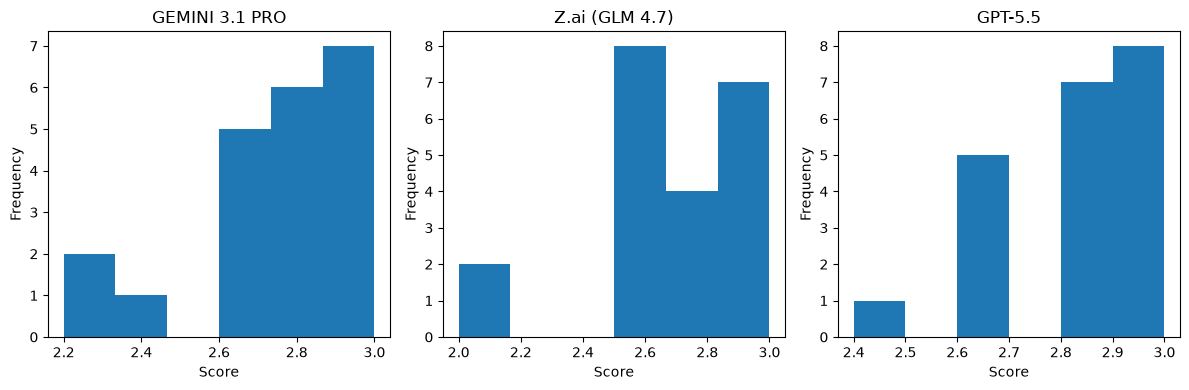

In [32]:
models = df["Model"].unique()

plt.figure(figsize=(12,4))

for i, model in enumerate(models):
    plt.subplot(1, len(models), i+1)

    plt.hist(
        df[df["Model"] == model]["Overall_Score"],
        bins=6
    )

    plt.title(model)
    plt.xlabel("Score")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Standard Deviation Table

In [33]:
consistency = (
    df.groupby("Model")["Overall_Score"]
      .agg(["mean", "std", "min", "max"])
      .round(2)
      .sort_values("std")
)

consistency

,mean,std,min,max
Model,,,,
GPT-5.5,2.81,0.18,2.4,3.0
GEMINI 3.1 PRO,2.74,0.25,2.2,3.0
Z.ai (GLM 4.7),2.71,0.29,2.0,3.0


# Final Leaderboard

In [37]:
leaderboard = (
    df.groupby("Model")
      .agg(
          Overall=("Overall_Score", "mean"),
          Correctness=("Correctness", "mean"),
          Completeness=("Completeness", "mean"),
          Instruction_Following=("Instruction_Following", "mean"),
          Format_Compliance=("Format_Compliance", "mean"),
          Conciseness=("Conciseness", "mean"),
          Confidence=("Confidence", "mean"),
          Avg_Tokens=("Response_length (words)", "mean")
      )
      .round(2)
      .sort_values("Overall", ascending=False)
      .reset_index()
)

leaderboard


,Model,Overall,Correctness,Completeness,Instruction_Following,Format_Compliance,Conciseness,Confidence,Avg_Tokens
0,GPT-5.5,2.81,2.81,2.71,2.90,2.90,2.62,3.0,124.14
1,GEMINI 3.1 PRO,2.74,2.86,2.76,2.86,2.95,2.24,3.0,185.86
2,Z.ai (GLM 4.7),2.71,2.90,2.76,2.90,2.95,2.00,3.0,223.24
